In [3]:
import numpy as np
import pandas as pd

data = pd.read_csv("data.csv")
data.head()

,Date,Count,Temperature,Pressure,Malfunction
0,4/12/81,6,66,50,0
1,11/12/81,6,70,50,1
2,3/22/82,6,69,50,0
3,11/11/82,6,68,50,0
4,4/04/83,6,67,50,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         23 non-null     object
 1   Count        23 non-null     int64 
 2   Temperature  23 non-null     int64 
 3   Pressure     23 non-null     int64 
 4   Malfunction  23 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.0+ KB


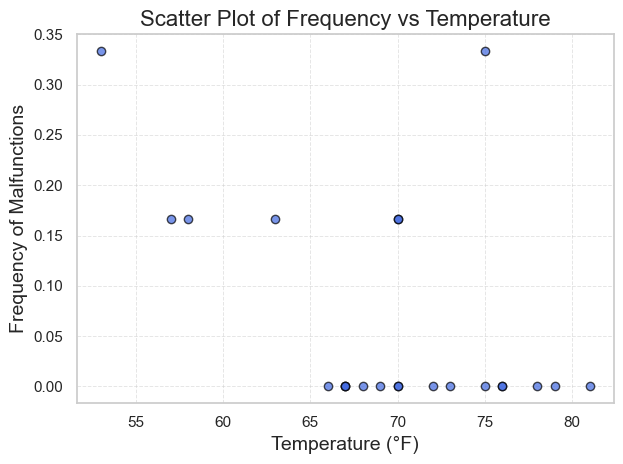

In [40]:
import matplotlib.pyplot as plt
data["Frequency"] = data["Malfunction"] / data["Count"]
plt.scatter(data["Temperature"], data["Frequency"], color='royalblue', label="Observed Data", edgecolors='black', alpha=0.7)

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)

plt.xlabel("Temperature (°F)", fontsize=14)
plt.ylabel("Frequency of Malfunctions", fontsize=14)
plt.title("Scatter Plot of Frequency vs Temperature", fontsize=16)

plt.tight_layout()

plt.show()


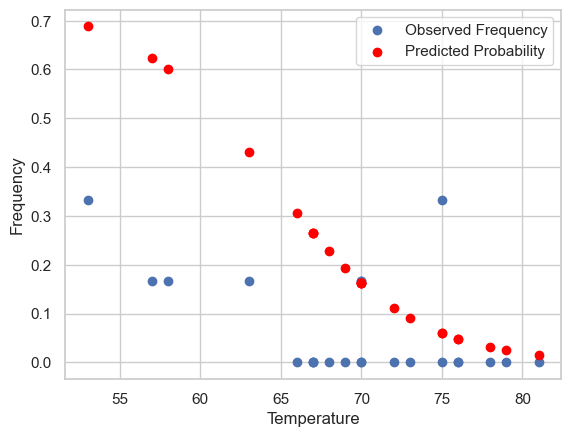

In [41]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

data["Frequency"] = data["Malfunction"] / data["Count"]

X = data[["Temperature"]]
y = data["Malfunction"]

logmodel = LogisticRegression(solver='lbfgs')
logmodel.fit(X, y, sample_weight=data["Count"])

data["Predicted_Prob"] = logmodel.predict_proba(X)[:,1]

plt.scatter(data["Temperature"], data["Frequency"], label="Observed Frequency")
plt.scatter(data["Temperature"], data["Predicted_Prob"], color="red", label="Predicted Probability")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
from sklearn.metrics import accuracy_score

y_pred = logmodel.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8261


c:\Users\Mahdi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


Model Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:              Frequency   No. Observations:                   23
Model:                            GLM   Df Residuals:                       21
Model Family:                Binomial   Df Model:                            1
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3.9210
Date:                Sun, 16 Mar 2025   Deviance:                       3.0144
Time:                        17:38:19   Pearson chi2:                     5.00
No. Iterations:                     6   Pseudo R-squ. (CS):            0.04355
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.0850      7.477  

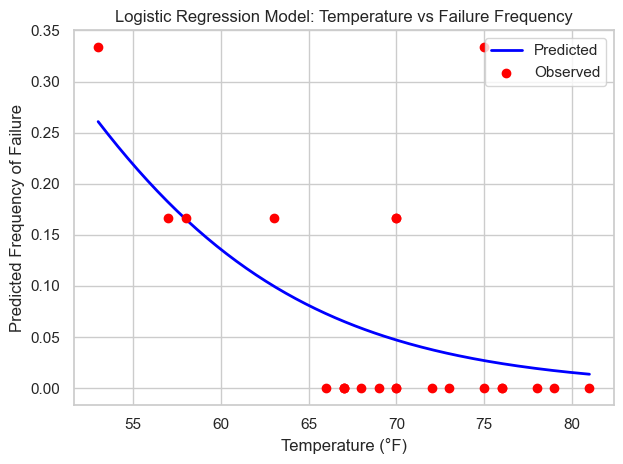

In [43]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

data["Intercept"] = 1
logmodel = sm.GLM(data['Frequency'], data[['Intercept', 'Temperature']], 
                  family=sm.families.Binomial(sm.families.links.logit())).fit()

print("Model Summary:")
print(logmodel.summary())

temperature_min = data["Temperature"].min()
temperature_max = data["Temperature"].max()

temperature_range = np.linspace(temperature_min, temperature_max, 200)
data_pred = pd.DataFrame({'Temperature': temperature_range, 'Intercept': 1})

data_pred['Frequency'] = logmodel.predict(data_pred[['Intercept', 'Temperature']])

plt.plot(data_pred['Temperature'], data_pred['Frequency'], label='Predicted', color='blue', linewidth=2)

plt.scatter(data["Temperature"], data["Frequency"], color='red', label='Observed', zorder=5)

plt.xlabel("Temperature (°F)")
plt.ylabel("Predicted Frequency of Failure")
plt.title("Logistic Regression Model: Temperature vs Failure Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


- **Number of Observations**: There are 23 data points used in the model.
- **Link Function**: The model uses the logit link function, which is appropriate for binary outcome variables (i.e., log-odds).
- **Log-Likelihood**: The log-likelihood is -3.9210, which gives an indication of how well the model fits the data. Lower values suggest poorer fit, but further comparison to other models is necessary.
- **Deviance**: The deviance is 3.0144, which is another indicator of model fit. Lower deviance indicates better model fit.
- **Pseudo R-squared**: The Pseudo R-squared is 0.04355, which is quite low. This suggests that the model explains a very small proportion of the variance in the dependent variable.
- **Coefficients**:
  - **Intercept**: The coefficient for the intercept is 5.0850, but its p-value is 0.496, meaning it is not statistically significant at common significance levels (e.g., 0.05).
  - **Temperature**: The coefficient for temperature is -0.1156, but the p-value is 0.316, indicating that temperature does not have a statistically significant effect on the frequency of malfunction in this model.
- **Statistical Significance**: Both the intercept and the temperature coefficient have high p-values, suggesting that neither of them are statistically significant predictors of the outcome.

Model Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:              Frequency   No. Observations:                   23
Model:                            GLM   Df Residuals:                       20
Model Family:                Binomial   Df Model:                            2
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3.8798
Date:                Sun, 16 Mar 2025   Deviance:                       2.9319
Time:                        17:36:13   Pearson chi2:                     4.48
No. Iterations:                     6   Pseudo R-squ. (CS):            0.04697
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept          

c:\Users\Mahdi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


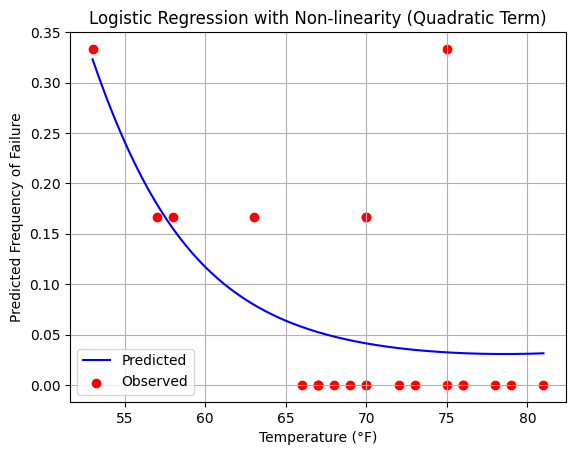

In [37]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Create non-linear feature (by a quadratic term)
data["Temperature_squared"] = data["Temperature"] ** 2
data["Intercept"] = 1

logmodel = sm.GLM(data['Frequency'], data[['Intercept', 'Temperature', 'Temperature_squared']], 
                  family=sm.families.Binomial(sm.families.links.logit())).fit()

print("Model Summary:")
print(logmodel.summary())


temperature_min = data["Temperature"].min()
temperature_max = data["Temperature"].max()

temperature_range = np.linspace(temperature_min, temperature_max, 200)
temperature_range_squared = temperature_range ** 2
data_pred = pd.DataFrame({'Temperature': temperature_range, 'Temperature_squared': temperature_range_squared, 'Intercept': 1})

data_pred['Frequency'] = logmodel.predict(data_pred[['Intercept', 'Temperature', 'Temperature_squared']])

plt.plot(data_pred['Temperature'], data_pred['Frequency'], label='Predicted', color='blue')

plt.scatter(data["Temperature"], data["Frequency"], color='red', label='Observed')

plt.xlabel("Temperature (°F)")
plt.ylabel("Predicted Frequency of Failure")
plt.title("Logistic Regression with Non-linearity (Quadratic Term)")
plt.legend()
plt.grid(True)
plt.show()


### Model Summary Analysis (with Quadratic Temperature Term):

- **Number of Observations**: 23
- **Link Function**: Logit (appropriate for binary outcomes)
- **Log-Likelihood**: -3.8798 (slightly better than the previous model)
- **Deviance**: 2.9319 (lower than the previous model, indicating slight improvement in model fit)
- **Pseudo R-squared**: 0.04697 (still low, model explains very little variance)
- **Coefficients**:
  - **Intercept**: Coefficient = 22.1261, p-value = 0.704 (not statistically significant)
  - **Temperature**: Coefficient = -0.6509, p-value = 0.720 (not statistically significant)
  - **Temperature Squared**: Coefficient = 0.0041, p-value = 0.766 (not statistically significant)
- **Conclusion**: Adding a quadratic term for temperature does not improve the model’s predictive power, as none of the coefficients are statistically significant.